# Phishing Email Classification Application

## Data Loading and Preparation

In [1]:
import pandas as pd

df = pd.read_csv("Phishing_Email.csv")
print("Loaded:", df.shape)
df.head()


Loaded: (18650, 3)


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


## Data Cleaning and Labeling

In [2]:
df = df.drop(columns="Unnamed: 0")
df.head()

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [3]:
df["Email Type"].value_counts()

Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

In [4]:
df["Email Type"] = df["Email Type"].astype(str).str.strip()
df["Email Type"].value_counts()



Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

In [5]:
df["Email Type"] = df["Email Type"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

In [6]:
df["Email Type"].value_counts()

Email Type
0    11322
1     7328
Name: count, dtype: int64

In [7]:
df["Email Type"].isna().sum()

np.int64(0)

## Data Exploration and Visualization

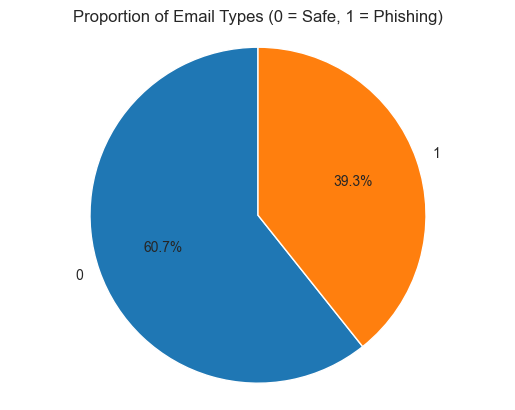

In [8]:
import matplotlib.pyplot as plt

# Chart shows class distribution of email types
df["Email Type"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proportion of Email Types (0 = Safe, 1 = Phishing)")

plt.ylabel("")  # removes default y-axis label
plt.axis("equal")  # keeps the pie circular
plt.show()

## Data Splitting

In [9]:
from sklearn.model_selection import train_test_split
#this is what the model reads
x = df["Email Text"]

# 0 = Safe Email, 1 = Phishing Email
y = df["Email Type"]

#split the data
# 80% for training / 20% for testing
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify= y
)

#print sizes to verify split
print("Training emails:", len(x_train))
print("Testing emails:", len(x_test))


Training emails: 14920
Testing emails: 3730


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    #turn email text into numbers
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
    #learn patterns from the numbers
    ("classifier", LogisticRegression(max_iter=1000))
])

In [11]:
# How many emails have missing text?
df["Email Text"].isna().sum()


np.int64(16)

## Handling Missing Email Text

In [12]:
# 1) Make sure Email Text is treated like text
df["Email Text"] = df["Email Text"].astype(str)

# 2) Convert common "empty" values into real missing values
df.loc[df["Email Text"].str.strip().isin(["", "nan", "None", "NULL"]), "Email Text"] = None

# 3) Drop rows where Email Text is missing
df = df.dropna(subset=["Email Text"])

print("Remaining rows after dropping blank emails:", len(df))


Remaining rows after dropping blank emails: 18631


In [13]:
from sklearn.model_selection import train_test_split
x = df["Email Text"]
y = df["Email Type"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify= y
)

print("Training emails: ", len(x_train))
print("Testing emails: ", len(x_test))

Training emails:  14904
Testing emails:  3727


## Model Training

In [14]:
model.fit(x_train, y_train)
print("Model trained.")


Model trained.


### Model Evaluation

Accuracy: 0.9624362758250604
Confusion matrix:
 [[2174   91]
 [  49 1413]]
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97      2265
           1       0.94      0.97      0.95      1462

    accuracy                           0.96      3727
   macro avg       0.96      0.96      0.96      3727
weighted avg       0.96      0.96      0.96      3727



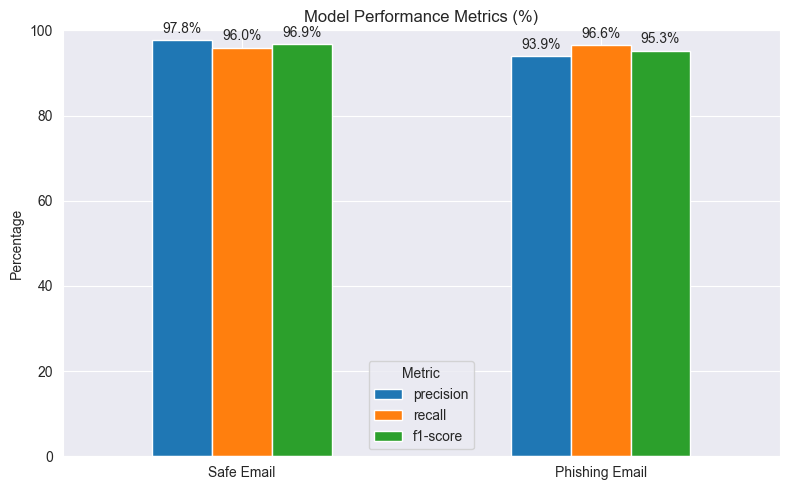

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#model predicts
pred = model.predict(x_test)

#checks for accuracy
print("Accuracy:", accuracy_score(y_test, pred))

#matrix showing safe/phishing emails and mistakes
print("Confusion matrix:\n", confusion_matrix(y_test, pred))

#Classification report
print("Classification report:\n", classification_report(y_test, pred))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# Generate classification report as DataFrame
report = classification_report(y_test, pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Rename class labels
df_metrics = df_report.loc[["0", "1"], ["precision", "recall", "f1-score"]]
df_metrics.index = ["Safe Email", "Phishing Email"]

# Convert to percentages
df_metrics = df_metrics * 100

# Plot
ax = df_metrics.plot(kind="bar", figsize=(8, 5))

ax.set_title("Model Performance Metrics (%)")
ax.set_ylabel("Percentage")
ax.set_ylim(0, 100)

# Add percentage labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


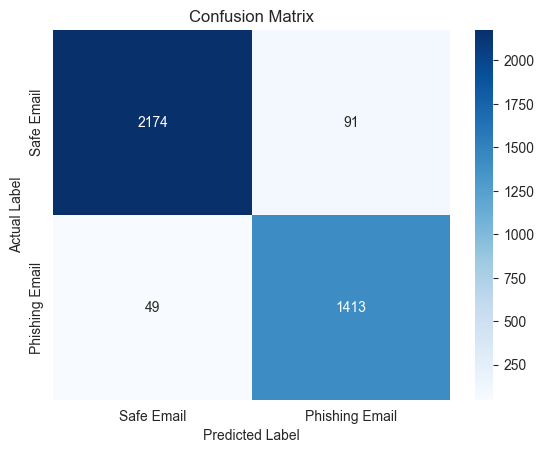

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate confusion matrix from test results
cm = confusion_matrix(y_test, pred)

# Plot confusion matrix as a heatmap
sns.heatmap(
    cm,
    annot=True,            # show values in each cell
    fmt="d",               # integer format
    cmap="Blues",
    xticklabels=["Safe Email", "Phishing Email"],   # predicted labels
    yticklabels=["Safe Email", "Phishing Email"]    # actual labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## User Application

In [17]:
# this functions lets user test an email
def classify_email(text):
    prediction = model.predict([text])[0]

    #model returns 0 for safe email & 1 for phishing
    #convert those 0 & 1s into readable output
    if prediction == 1:
        return "Phishing Email"
    else:
        return "Safe Email"

classify_email("Urgent: verify your account immediately by clicking this link")

'Phishing Email'

In [18]:
# Run this for user test
try:
    user_email = input("Paste the email text you want to classify:\n")

    if not user_email.strip():
        print("No input provided. Please paste an email to classify.")
    else:
        result = classify_email(user_email)
        print("Prediction:", result)

except KeyboardInterrupt:
    print("\nInput cancelled by user.")


Input cancelled by user.


Example inputs the evaluator may try:
- "Urgent: verify your account immediately"
- "Hey Jim, can you help me move these boxes tomorrow?"
- "Your account has been temporarily suspended. Please click the link below to verify your information within 24 hours."
- "Hi Sarah, just checking if our meeting is still scheduled for tomorrow at 2 PM. Let me know."
- "We detected unusual activity on your bank account. Confirm your details immediately to avoid permanent closure."
